In [215]:
import numpy as np
import mne
from pathlib import Path

import matplotlib.pyplot as plt

from scipy.signal import resample_poly, find_peaks, welch
from scipy.stats import gaussian_kde

In [214]:
dataset_path = Path("BCI4_2a")
subject_id = 3

In [216]:
def read_subject_epochs(subject_id: int|list, dataset_path: Path,
                        is_train: bool = True,
                        l_freq: float = 4.0,
                        h_freq: float = 37.0,
                        tmin: float = -0.5,
                        tmax: float = 4.5):
    """
    Загружает EEG одного субъекта BCI IV 2a и возвращает:
    epochs, X, y, label_names
    """
    train_eval_label = "T" if is_train else "E"

    if type(subject_id) == int:
        subject_prefix = f"A0{subject_id}"
        subject_training_data_path = dataset_path / (subject_prefix + f"{train_eval_label}.gdf")
        raw = mne.io.read_raw_gdf(subject_training_data_path, preload=True)
    else:
        raw = []
        for i in subject_id:
            subject_prefix = f"A0{i}"
            subject_training_data_path = dataset_path / (subject_prefix + f"{train_eval_label}.gdf")
            raw.append(mne.io.read_raw_gdf(subject_training_data_path, preload=True))
        raw = mne.concatenate_raws(raw)
    bci_channels = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2',
    'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz'
    ]

    # Создаем соответствие с индексами каналов в данных
    # (если каналы называются иначе)
    if raw.ch_names[0].startswith('EEG'):
        rename_dict = dict()
        for key, value in zip(raw.ch_names[:-3], bci_channels):
            rename_dict[key] = value
        raw.rename_channels(rename_dict)
    raw.filter(l_freq, h_freq, verbose=False)
    raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])

    raw.set_montage('standard_1020')

    events, event_dict = mne.events_from_annotations(raw)

    event_id = {
        "left": event_dict["769"],
        "right": event_dict["770"],
        "foot": event_dict["771"],
        "tongue": event_dict["772"],
    }

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose=False
    )

    X = epochs.get_data()  # (n_epochs, n_channels, n_times)
    y_raw = epochs.events[:, -1]

    label_map = {
        event_dict["769"]: 0,
        event_dict["770"]: 1,
        event_dict["771"]: 2,
        event_dict["772"]: 3,
    }
    inv_label_map = {0: "left", 1: "right", 2: "foot", 3: "tongue"}

    y = np.array([label_map[i] for i in y_raw])

    return epochs, X, y, inv_label_map

In [217]:
epochs, X, y, inv_label_map = read_subject_epochs(subject_id, dataset_path, l_freq=1, h_freq=40)

Extracting EDF parameters from c:\Users\HP\Documents\GitHub\Statistical_Tests\BCI4_2a\A03T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 660529  =      0.000 ...  2642.116 secs...


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


In [174]:
ep_list[1]

<Epochs | 288 events (all good), -0.5 – 4.5 s (baseline off), ~60.5 MiB, data loaded,
 'left': 72
 'right': 72
 'foot': 72
 'tongue': 72>

In [175]:
epochs

array([0, 1, 1, 0, 1, 0, 1, 2, 1, 3, 0, 2, 1, 0, 3, 3, 3, 3, 3, 0, 2, 1,
       0, 0, 2, 3, 0, 2, 2, 2, 0, 1, 0, 1, 1, 0, 1, 2, 1, 2, 2, 3, 2, 2,
       3, 3, 3, 3, 3, 2, 1, 0, 0, 1, 2, 3, 1, 2, 0, 0, 0, 3, 1, 1, 0, 0,
       2, 0, 1, 3, 3, 2, 0, 3, 3, 1, 3, 3, 1, 0, 1, 2, 2, 2, 3, 2, 0, 3,
       1, 2, 1, 2, 3, 1, 2, 0, 0, 0, 3, 1, 0, 2, 0, 2, 1, 3, 0, 2, 2, 0,
       2, 1, 3, 3, 3, 2, 0, 3, 1, 3, 1, 0, 2, 1, 0, 2, 2, 0, 2, 3, 3, 1,
       0, 1, 3, 1, 3, 2, 1, 1, 1, 2, 3, 0, 1, 3, 0, 2, 2, 3, 0, 0, 2, 1,
       3, 3, 3, 1, 0, 2, 1, 3, 0, 3, 2, 1, 3, 3, 0, 1, 1, 2, 3, 1, 0, 0,
       3, 1, 0, 2, 1, 1, 2, 0, 3, 2, 2, 2, 2, 0, 1, 0, 1, 0, 0, 2, 2, 1,
       2, 3, 0, 3, 0, 0, 1, 3, 2, 1, 3, 2, 3, 2, 3, 1, 1, 3, 0, 1, 1, 1,
       2, 3, 0, 3, 0, 2, 0, 3, 0, 2, 0, 1, 2, 2, 3, 0, 1, 3, 1, 2, 2, 0,
       3, 1, 3, 0, 0, 2, 2, 1, 3, 1, 1, 0, 1, 3, 3, 1, 1, 1, 1, 3, 3, 2,
       3, 0, 1, 2, 1, 0, 3, 0, 3, 0, 0, 0, 0, 2, 2, 3, 1, 2, 2, 2, 3, 2,
       0, 2])

In [176]:
from mne.time_frequency import psd_array_welch

In [177]:
fmin, fmax = 2, 40  # Диапазон частот
n_fft = 256
s_freq = 250


In [178]:
# freqs = np.arange(n_fft // 2 + 1, dtype=float) * (s_freq / n_fft)
# freq_mask = (freqs >= fmin) & (freqs <= fmax)
# freqs = freqs[freq_mask]
# len(freqs)

In [179]:
# psds, freqs = psd_array_welch(X, s_freq, fmin=fmin, fmax=fmax, n_fft=n_fft, n_jobs=14)
spectrum = epochs.compute_psd(method="welch", fmin=fmin, fmax=fmax, n_fft=n_fft, n_jobs=None)


Effective window size : 1.024 (s)


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   4 out of  14 | elapsed:    2.4s remaining:    6.0s
[Parallel(n_jobs=14)]: Done   7 out of  14 | elapsed:    2.5s remaining:    2.5s
[Parallel(n_jobs=14)]: Done  10 out of  14 | elapsed:    2.7s remaining:    1.1s
[Parallel(n_jobs=14)]: Done  14 out of  14 | elapsed:    2.7s finished


Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


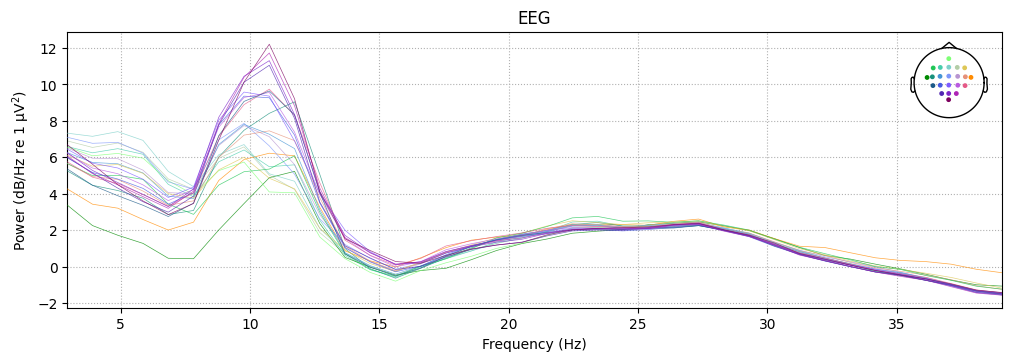

In [180]:
spectrum.plot()

In [107]:
spectrum.get_data()

array([[[6.67395179e-12, 7.57232058e-12, 8.84584199e-12, ...,
         1.52355819e-13, 1.15869475e-13, 9.35572716e-14],
        [6.29946888e-12, 5.56691397e-12, 5.39959717e-12, ...,
         2.78103976e-13, 2.33945284e-13, 7.16881796e-14],
        [7.02331931e-12, 8.27371105e-12, 1.02189355e-11, ...,
         2.47483585e-13, 1.48656436e-13, 6.34729410e-14],
        ...,
        [3.08798911e-12, 4.49222761e-12, 5.26130601e-12, ...,
         3.16056292e-13, 2.00372501e-13, 1.16685176e-13],
        [2.94846240e-12, 4.95419742e-12, 4.76468443e-12, ...,
         2.61020840e-13, 1.90734112e-13, 1.58471453e-13],
        [2.22586535e-12, 2.73450559e-12, 3.67833787e-12, ...,
         3.74031096e-13, 2.43558192e-13, 1.59190164e-13]],

       [[3.68150066e-12, 3.40798550e-12, 5.15194410e-12, ...,
         2.00505399e-13, 1.38402775e-13, 2.47949132e-13],
        [3.94957149e-12, 2.58114776e-12, 3.26950603e-12, ...,
         1.96708010e-13, 1.70327542e-13, 2.86529258e-13],
        [4.38384340e-12, 

In [182]:
spectrum.freqs

array([ 2.9296875,  3.90625  ,  4.8828125,  5.859375 ,  6.8359375,
        7.8125   ,  8.7890625,  9.765625 , 10.7421875, 11.71875  ,
       12.6953125, 13.671875 , 14.6484375, 15.625    , 16.6015625,
       17.578125 , 18.5546875, 19.53125  , 20.5078125, 21.484375 ,
       22.4609375, 23.4375   , 24.4140625, 25.390625 , 26.3671875,
       27.34375  , 28.3203125, 29.296875 , 30.2734375, 31.25     ,
       32.2265625, 33.203125 , 34.1796875, 35.15625  , 36.1328125,
       37.109375 , 38.0859375, 39.0625   ])

In [183]:
from scipy.stats import ttest_ind
from typing import Dict, Tuple

In [184]:
def group_by_bands(spectrum: mne.time_frequency.EpochsSpectrum, bands: Dict[str, Tuple[float, float]]):
    band_powers = dict()
    for band_name, (f_min, f_max) in bands.items():
        band_powers[band_name] = np.mean(spectrum.get_data(fmin=f_min, fmax=f_max), axis=2)
    
    return band_powers

In [185]:
bands = {'Delta (0-4 Hz)': (0, 4), 'Theta (4-8 Hz)': (4, 8),
         'Alpha (8-12 Hz)': (8, 12), 'Beta (12-30 Hz)': (12, 30),
         'Gamma (30-45 Hz)': (30, 45)}

In [186]:
band_powers_left = group_by_bands(spectrum['left'], bands)
band_powers_right = group_by_bands(spectrum['foot'], bands)

In [187]:
band_powers_left

{'Delta (0-4 Hz)': array([[7.12313618e-12, 5.93319142e-12, 7.64851518e-12, ...,
         3.79010836e-12, 3.95132991e-12, 2.48018547e-12],
        [3.74619105e-12, 2.95060416e-12, 5.34831596e-12, ...,
         2.73517812e-12, 2.27758701e-12, 1.68706242e-12],
        [3.85673527e-12, 2.49358653e-12, 3.70879098e-12, ...,
         2.16035678e-12, 2.18524852e-12, 2.76693703e-12],
        ...,
        [8.60302313e-12, 5.10575140e-12, 7.36298767e-12, ...,
         4.56173837e-12, 4.73783424e-12, 4.16367617e-12],
        [1.69489033e-12, 1.36177187e-12, 1.83142130e-12, ...,
         1.26864387e-12, 1.10451185e-12, 3.48871350e-12],
        [4.44606820e-12, 3.18447287e-12, 3.86411460e-12, ...,
         2.43836823e-12, 2.62015018e-12, 3.58073803e-12]]),
 'Theta (4-8 Hz)': array([[5.05974228e-12, 3.86811817e-12, 5.85094792e-12, ...,
         3.17767423e-12, 2.72248940e-12, 2.93729509e-12],
        [2.55288675e-12, 1.71504184e-12, 2.99084408e-12, ...,
         2.59457675e-12, 2.10426646e-12, 2.4483

In [188]:
def statistical_test(band_powers_1, band_powers_2, stat_test_func, stat_test_func_kwargs=dict()):
    result_dict = dict()
    p_value_dict = dict()
    statistic_dict = dict()

    for (band, epoch_channel_power_array_1), epoch_channel_power_array_2 in zip(band_powers_1.items(), band_powers_2.values()):
        channel_epoch_power_array_1 = np.swapaxes(epoch_channel_power_array_1, 0, 1)
        channel_epoch_power_array_2 = np.swapaxes(epoch_channel_power_array_2, 0, 1)
        result_dict[band] = list()
        p_value_dict[band] = list()
        statistic_dict[band] = list()
        for channel, (epoch_power_array_1, epoch_power_array_2) in enumerate(zip(channel_epoch_power_array_1, channel_epoch_power_array_2)):
            result = ttest_ind(epoch_power_array_1, epoch_power_array_2, **stat_test_func_kwargs)
            result_dict[band].append(result)
            p_value_dict[band].append(result.pvalue)
            statistic_dict[band].append(result.statistic)
            if result.pvalue < 0.05:
                 print(result.pvalue, band)
        result_dict[band] = np.array(result_dict[band])
        p_value_dict[band] = np.array(p_value_dict[band])
        statistic_dict[band] = np.array(statistic_dict[band])

    return result_dict, p_value_dict, statistic_dict

In [189]:
result_dict, p_value_dict, statistic_dict = statistical_test(band_powers_left, band_powers_right, stat_test_func=ttest_ind, stat_test_func_kwargs = {"equal_var": False})

0.03652001285048502 Delta (0-4 Hz)
0.03680189869304388 Delta (0-4 Hz)
0.04814863775847812 Delta (0-4 Hz)
0.04382341977187028 Delta (0-4 Hz)
0.0238156877360453 Delta (0-4 Hz)
0.026408554697544398 Delta (0-4 Hz)
0.0260430445166795 Delta (0-4 Hz)
0.0339680666495219 Delta (0-4 Hz)
0.038136228031028334 Delta (0-4 Hz)
0.004598129405263001 Delta (0-4 Hz)
0.003037412508437138 Delta (0-4 Hz)
0.0032140681919897154 Delta (0-4 Hz)
0.004141252205329846 Delta (0-4 Hz)
0.0036616506591381943 Delta (0-4 Hz)
0.0003147531214046578 Delta (0-4 Hz)
0.00018909400021910184 Delta (0-4 Hz)
7.088990643206445e-05 Delta (0-4 Hz)
0.00036718810244754 Delta (0-4 Hz)
0.03809189561551296 Theta (4-8 Hz)
0.015663352358996147 Theta (4-8 Hz)
0.016801167657467534 Theta (4-8 Hz)
0.026649701960104265 Theta (4-8 Hz)
0.0014466333964282835 Alpha (8-12 Hz)
1.646836865319607e-05 Alpha (8-12 Hz)
2.1319594464038972e-05 Alpha (8-12 Hz)
0.00011762562004327592 Alpha (8-12 Hz)
4.00175069125476e-05 Alpha (8-12 Hz)
8.737528843645118e-06 A

In [190]:
epochs.info["dig"]
pass

In [191]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

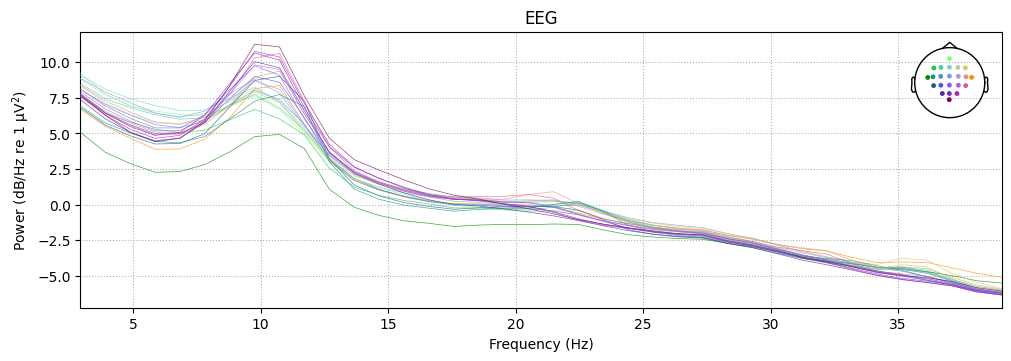

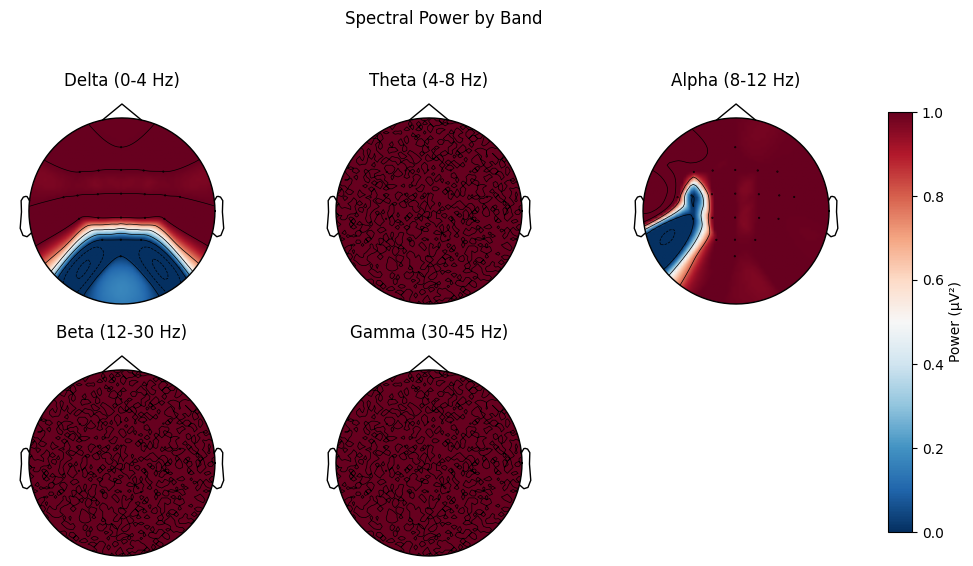

In [192]:
def plot_stattest_result(data):
    fig = plt.figure(figsize=(12, 6))
    gs = gridspec.GridSpec(2, 3, figure=fig)
    gs.update(right=0.85)  # место под colorbar

    # Единый vmin/vmax для сравнения
    all_vals = np.concatenate([np.atleast_1d(v).ravel() for v in data.values()])
    vlim = (np.percentile(all_vals, 5), np.percentile(all_vals, 95))
    vlim = (0, 1)


    for idx, (name, _) in enumerate(bands.items()):
        ax = fig.add_subplot(gs[idx // 3, idx % 3])
        data[name] = np.array(list(map(lambda x: 0 if x < 0.005 else 1, data[name])))
        im, cntr = mne.viz.plot_topomap(
            data[name], pos=epochs.info, axes=ax, show=False,
            vlim=vlim, cmap='RdBu_r'
        )
        ax.set_title(name)

    # Общий colorbar
    cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Power (µV²)')
    plt.suptitle('Spectral Power by Band', y=1.02)
    plt.show()

plot_stattest_result(p_value_dict)

In [119]:
from scipy.stats import mannwhitneyu

In [219]:
spectrum.freqs

array([ 2.9296875,  3.90625  ,  4.8828125,  5.859375 ,  6.8359375,
        7.8125   ,  8.7890625,  9.765625 , 10.7421875, 11.71875  ,
       12.6953125, 13.671875 , 14.6484375, 15.625    , 16.6015625,
       17.578125 , 18.5546875, 19.53125  , 20.5078125, 21.484375 ,
       22.4609375, 23.4375   , 24.4140625, 25.390625 , 26.3671875,
       27.34375  , 28.3203125, 29.296875 , 30.2734375, 31.25     ,
       32.2265625, 33.203125 , 34.1796875, 35.15625  , 36.1328125,
       37.109375 , 38.0859375, 39.0625   ])

0.0365139032954508 Delta (0-4 Hz)
0.03678933486988439 Delta (0-4 Hz)
0.04800240880948722 Delta (0-4 Hz)
0.043790086492502905 Delta (0-4 Hz)
0.023811238099432495 Delta (0-4 Hz)
0.026406296625781908 Delta (0-4 Hz)
0.02604135703744719 Delta (0-4 Hz)
0.033957212681354265 Delta (0-4 Hz)
0.038131535092095964 Delta (0-4 Hz)
0.004596948599405364 Delta (0-4 Hz)
0.0030364817546494932 Delta (0-4 Hz)
0.0032133081837823424 Delta (0-4 Hz)
0.004141150580678635 Delta (0-4 Hz)
0.0036609440985149277 Delta (0-4 Hz)
0.0003118457622274759 Delta (0-4 Hz)
0.00018870380046986539 Delta (0-4 Hz)
7.082212372107612e-05 Delta (0-4 Hz)
0.000363645008632481 Delta (0-4 Hz)
0.037965766197222556 Theta (4-8 Hz)
0.015419037433886522 Theta (4-8 Hz)
0.016536897180704706 Theta (4-8 Hz)
0.026347768952000125 Theta (4-8 Hz)
0.0014190259388814088 Alpha (8-12 Hz)
1.4624439750949504e-05 Alpha (8-12 Hz)
1.935031455764336e-05 Alpha (8-12 Hz)
0.00011091899624894121 Alpha (8-12 Hz)
3.7237233868942566e-05 Alpha (8-12 Hz)
7.80875851707

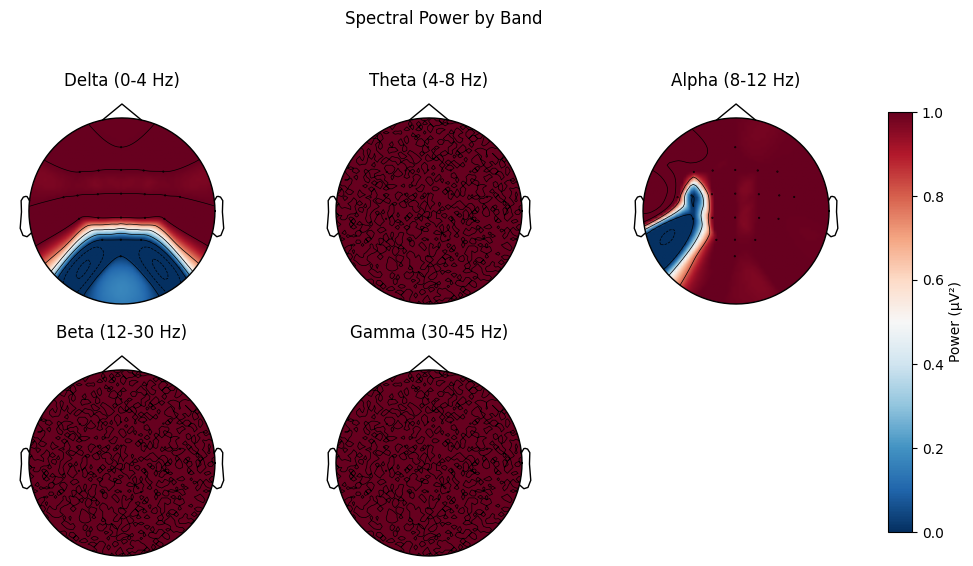

In [194]:
result_dict, p_value_dict, statistic_dict = statistical_test(band_powers_left, band_powers_right, stat_test_func=mannwhitneyu)
plot_stattest_result(p_value_dict)

In [121]:
p_value_dict

{'Delta (0-4 Hz)': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'Theta (4-8 Hz)': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 'Alpha (8-12 Hz)': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'Beta (12-30 Hz)': array([1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1]),
 'Gamma (30-45 Hz)': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}

In [122]:
adj = mne.channels.find_ch_adjacency(epochs.info, 'eeg')

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 22


In [196]:
adj[1]

['Fz',
 'FC3',
 'FC1',
 'FCz',
 'FC2',
 'FC4',
 'C5',
 'C3',
 'C1',
 'Cz',
 'C2',
 'C4',
 'C6',
 'CP3',
 'CP1',
 'CPz',
 'CP2',
 'CP4',
 'P1',
 'Pz',
 'P2',
 'POz']

In [197]:
print(adj[0].toarray()[4])

[1 0 0 1 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0]


In [198]:
left_sample, right_sample = spectrum['left'], spectrum['right']

In [199]:
left_sample.shape

(576, 22, 38)

In [200]:
time_adjacency = mne.stats.combine_adjacency(
    left_sample.shape[2], adj[0]
)

In [201]:
time_adjacency

<COOrdinate sparse array of dtype 'float64'
	with 6492 stored elements and shape (836, 836)>

In [202]:
# print(time_adjacency[88])

In [203]:
left_sample.data

array([[[6.67395179e-12, 7.57232058e-12, 8.84584199e-12, ...,
         1.52355819e-13, 1.15869475e-13, 9.35572716e-14],
        [6.29946888e-12, 5.56691397e-12, 5.39959717e-12, ...,
         2.78103976e-13, 2.33945284e-13, 7.16881796e-14],
        [7.02331931e-12, 8.27371105e-12, 1.02189355e-11, ...,
         2.47483585e-13, 1.48656436e-13, 6.34729410e-14],
        ...,
        [3.08798911e-12, 4.49222761e-12, 5.26130601e-12, ...,
         3.16056292e-13, 2.00372501e-13, 1.16685176e-13],
        [2.94846240e-12, 4.95419742e-12, 4.76468443e-12, ...,
         2.61020840e-13, 1.90734112e-13, 1.58471453e-13],
        [2.22586535e-12, 2.73450559e-12, 3.67833787e-12, ...,
         3.74031096e-13, 2.43558192e-13, 1.59190164e-13]],

       [[4.27880982e-12, 3.21357227e-12, 5.11346698e-12, ...,
         2.88530229e-13, 2.26881304e-13, 1.46175603e-13],
        [3.51715101e-12, 2.38405732e-12, 2.41547968e-12, ...,
         2.26214816e-13, 1.76069274e-13, 1.49751945e-13],
        [5.70226999e-12, 

In [204]:
from matplotlib.pylab import axes
left_sample_reshaped = left_sample.data.transpose(0, 2, 1)
right_sample_reshaped = right_sample.data.transpose(0, 2, 1)
left_sample_reshaped.shape

(576, 38, 22)

In [210]:
f_thresh=dict(start=0, step=0.2)

In [ ]:
import scipy
p_unc = 0.005
dfn = 1  # степени свободы числителя (между группами) = количество групп - 1
dfd = (left_sample_reshaped.shape[0] + right_sample_reshaped.shape[0] - dfn*2)  # внутригрупповые степени свободы
f_thresh = scipy.stats.f.ppf(1 - p_unc, dfn, dfd)
f_thresh

142

In [211]:
F_obs, clusters, cluster_pv, H0 = mne.stats.permutation_cluster_test([left_sample_reshaped, right_sample_reshaped], threshold=f_thresh, n_permutations=4000,
                                   adjacency=time_adjacency, seed = 42, n_jobs = 5, check_disjoint=True, out_type='mask')
#significant_points = cluster_pv.reshape(F_obs.shape).T < 0.05
#print(str(significant_points.sum()) + " points selected by TFCE ...")

stat_fun(H1): min=1.2051531726577493e-06 max=45.57362597557229
No disjoint adjacency sets found
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/3999 [00:00<?,       ?it/s]

In [209]:
cluster_pv

array([0.78625, 0.6985 , 0.52725])

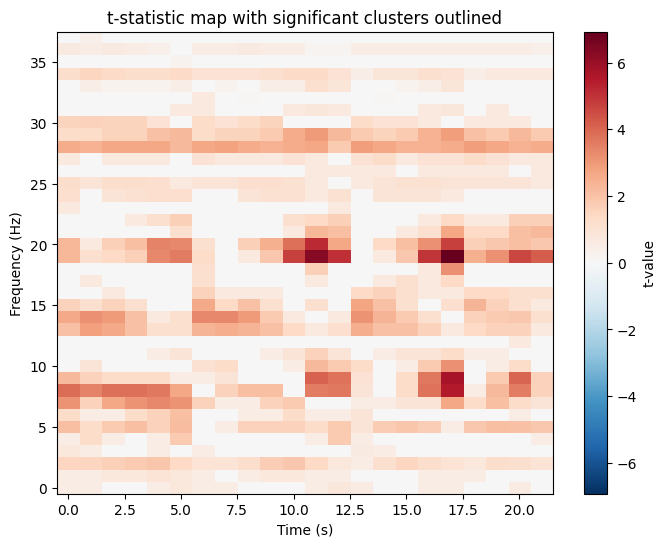

In [212]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Выбираем значимые кластеры (p < 0.05)
significant_clusters = [mask for mask, p in zip(clusters, cluster_pv) if p < 0.05]

# Создаём общую маску значимых точек (объединение всех значимых кластеров)
sig_mask = np.zeros_like(F_obs, dtype=bool)
for mask in significant_clusters:
    sig_mask |= mask

# Настройка фигуры
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Отрисовка карты t-статистики
# Для двустороннего теста используем дивергирующую цветовую карту
# Симметричная нормализация вокруг нуля
vmax = max(abs(F_obs.min()), abs(F_obs.max()))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im = ax.imshow(F_obs, origin='lower', aspect='auto', cmap='RdBu_r', norm=norm)
               #,extent=[times[0], times[-1], freqs[0], freqs[-1]])
plt.colorbar(im, ax=ax, label='t-value')

# Наложение контуров значимых кластеров
for mask in significant_clusters:
    # contour ожидает массив, где 1 = внутри, 0 = снаружи
    # Используем уровни [0.5] для обводки границы
    ax.contour(mask, levels=[0.5], colors='black', linewidths=1)
               #,extent=[times[0], times[-1], freqs[0], freqs[-1]])

# Оформление осей
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('t-statistic map with significant clusters outlined')

#plt.tight_layout()
plt.show()

In [ ]:
cluster_pv

array([1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 0.99975, 1.     , 0.99975,
       0.99975, 1.     , 0.999  , 0.999  , 1.     , 0.99975, 0.99975,
       1.     , 0.999  , 0.9995 , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       0.99975, 0.999  , 1.     , 1.     , 1.     , 1.     , 0.99975,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.  

In [ ]:
cluster_pv

array([0.0085, 0.124 , 0.037 ])

In [ ]:
H0.shape

(4000,)

In [ ]:
clusters[0]

(array([7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9]),
 array([10, 11, 12, 16, 17, 20,  5, 10, 11, 12, 16, 17, 20, 11, 12, 16, 17]))

In [ ]:
print(min(cluster_pv))

0.466


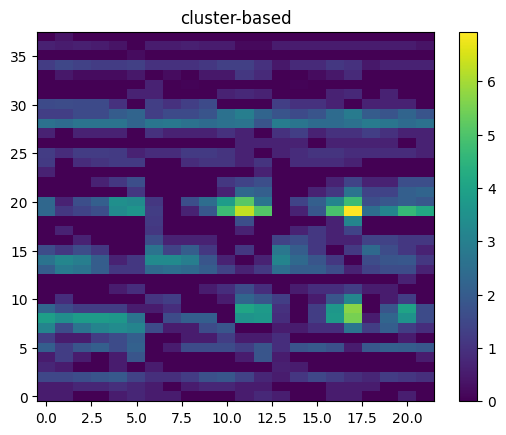

In [213]:
plt.imshow(F_obs, origin='lower', aspect='auto')
plt.colorbar()
plt.title('cluster-based')
plt.show()

In [ ]:
choosen = []
for i, val in enumerate(cluster_pv):
    if val < 0.05: choosen.append((i, val))

choosen

[(0, np.float64(0.0085)), (2, np.float64(0.037))]

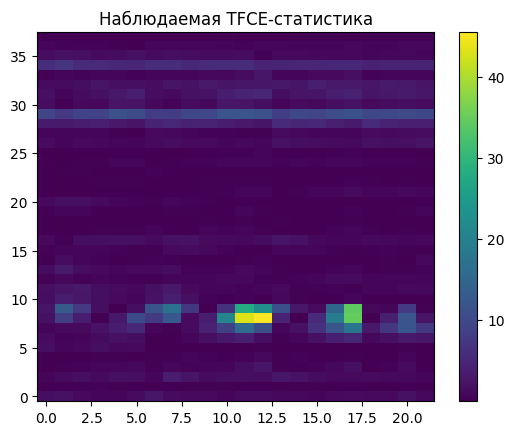

In [138]:
import matplotlib.pyplot as plt
plt.imshow(F_obs, origin='lower', aspect='auto')
plt.colorbar()
plt.title("Наблюдаемая TFCE-статистика")
plt.show()

In [ ]:
def plot_stattest_result(data):
    fig = plt.figure(figsize=(12, 6))
    gs = gridspec.GridSpec(2, 3, figure=fig)
    gs.update(right=0.85)  # место под colorbar

    # Единый vmin/vmax для сравнения
    all_vals = np.concatenate([np.atleast_1d(v).ravel() for v in data.values()])
    vlim = (np.percentile(all_vals, 5), np.percentile(all_vals, 95))
    vlim = (0, 1)


    for idx, (name, _) in enumerate(bands.items()):
        ax = fig.add_subplot(gs[idx // 3, idx % 3])
        data[name] = np.array(list(map(lambda x: 0 if x < 0.005 else 1, data[name])))
        im, cntr = mne.viz.plot_topomap(
            data[name], pos=epochs.info, axes=ax, show=False,
            vlim=vlim, cmap='RdBu_r'
        )
        ax.set_title(name)

    # Общий colorbar
    cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Power (µV²)')
    plt.suptitle('Spectral Power by Band', y=1.02)
    plt.show()


TypeError: 'function' object is not subscriptable

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mne

def plot_cbpt_results(F_obs, clusters, cluster_pv, info, 
                      left_data, right_data,
                      p_threshold=0.005,
                      bands=None):
    """
    Визуализация результатов cluster-based permutation test.
    
    Parameters
    ----------
    F_obs, clusters, cluster_pv : результаты cbpt
    info : mne.Info
    left_data, right_data : данные групп (n_subjects, n_channels, n_times)
    p_threshold : порог значимости
    bands : dict - словарь с названиями диапазонов (если нужны несколько подграфиков)
    """
    
    # Находим значимые кластеры
    significant_clusters = np.where(cluster_pv < p_threshold)[0]
    
    # Рассчитываем разницу между группами и усредняем по времени
    mean_left = np.mean(left_data, axis=0)  # (n_channels, n_times)
    mean_right = np.mean(right_data, axis=0)
    diff = np.mean(mean_left - mean_right, axis=1)  # (n_channels,)
    
    # Создаем маску значимых каналов
    masks = dict()
    for band_name in bands.keys():
        masks[band_name] = np.zeros(diff.shape[0], dtype=bool)
    for band_name, (band_low, band_high) in bands.items():
        space_inds = set()
        for i_clu in significant_clusters:
            for freq_id, channel in zip(clusters[i_clu][0], clusters[i_clu][1]):
                if band_low <= left_sample.freqs[freq_id] < band_high:
                    space_inds.add(channel)
        masks[band_name][list(space_inds)] = True
    
    # Преобразуем в бинарные данные (0/1) как в вашей функции
    data = {}

    for name in bands:
        data[name] = np.array([1 if m else 0 for m in masks[name]])
    
    # Создаем фигуру
    fig = plt.figure(figsize=(12, 6))
    gs = gridspec.GridSpec(2, 3, figure=fig)
    gs.update(right=0.85)
    
    # Единый vlim
    vlim = (0, 1)
    
    # Рисуем топоплоты
    for idx, (name, _) in enumerate(data.items()):
        ax = fig.add_subplot(gs[idx // 3, idx % 3])
        im, cntr = mne.viz.plot_topomap(
            data[name], pos=info, axes=ax, show=False,
            vlim=vlim, cmap='RdBu_r'
        )
        ax.set_title(f'{name}\n{np.sum(mask)} significant channels')
    
    # Общий colorbar
    cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Significance (0=no, 1=yes)')
    
    # Заголовок с информацией о кластерах
    cluster_info = ', '.join([f'Cl{idx}(p={cluster_pv[idx]:.3f})' 
                              for idx in significant_clusters])
    plt.suptitle(f'Cluster-Based Permutation Test\nSignificant clusters: {cluster_info}', y=1.02)
    plt.show()

(array([7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9]), array([10, 11, 12, 16, 17, 20,  5, 10, 11, 12, 16, 17, 20, 11, 12, 16, 17]))
(array([29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29,
       29, 29, 29]), array([ 0,  2,  3,  4,  5,  6,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21]))
(array([7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9]), array([10, 11, 12, 16, 17, 20,  5, 10, 11, 12, 16, 17, 20, 11, 12, 16, 17]))
(array([29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29,
       29, 29, 29]), array([ 0,  2,  3,  4,  5,  6,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21]))
(array([7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9]), array([10, 11, 12, 16, 17, 20,  5, 10, 11, 12, 16, 17, 20, 11, 12, 16, 17]))
(array([29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29,
       29, 29, 29]), array([ 0,  2,  3,  4,  5,  6,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21]))
(array(

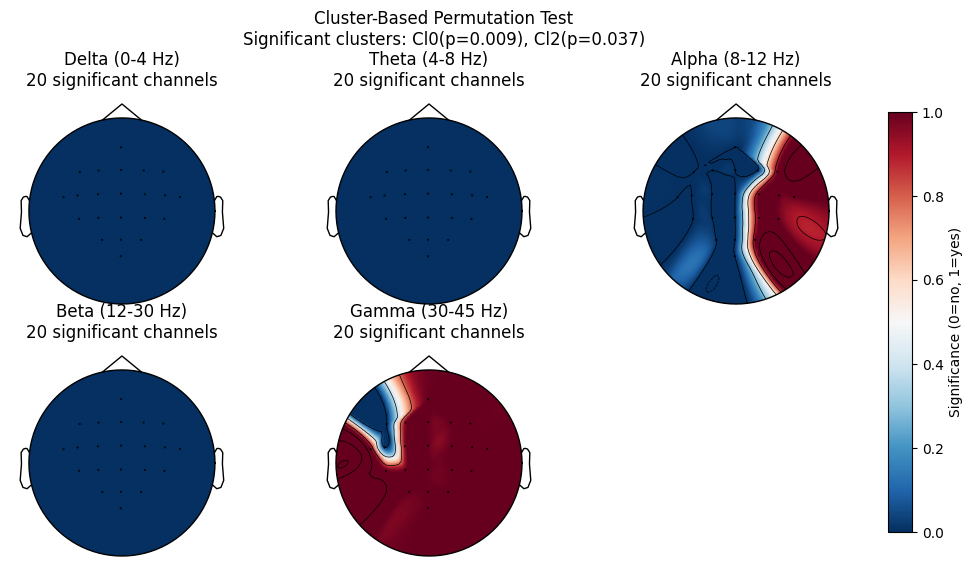

In [187]:
plot_cbpt_results(F_obs, clusters, cluster_pv, epochs.info, 
                      left_sample, right_sample,
                      p_threshold=0.05,
                      bands=bands)

In [ ]:
choosen = []
for i, val in enumerate(cluster_pv1):
    if val < 0.95: choosen.append((i, val))

choosen

np.float64(2.9296875)

In [ ]:
cluster_pv1

array([1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 0.99625, 1.     ,
       1.     , 1.     , 1.     , 0.99975, 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 0.999  , 1.     , 1.     ,
       0.999  , 0.998  , 0.99625, 1.     , 1.     , 1.     , 1.     ,
       0.99975, 0.99

In [ ]:
clusters[192]

IndexError: list index out of range